# Spotify Hit Song Prediction

This project aims to predict whether a song will become a hit on Spotify using machine learning techniques.

The prediction is based on Spotify audio features such as danceability, energy, loudness, tempo, and valence.

Machine learning models including Logistic Regression, Random Forest, and XGBoost are trained and compared based on their accuracy to determine the best performing model.

## Dataset Description

The dataset contains Spotify tracks along with several audio features that describe musical characteristics.

Important features used in this project include:

- Danceability
- Energy
- Loudness
- Speechiness
- Acousticness
- Instrumentalness
- Liveness
- Valence
- Tempo
- Popularity

A binary target variable called **hit** is created where:

- Hit = 1 if popularity > 70
- Hit = 0 otherwise

### Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

import joblib

## Data Preprocessing

Data preprocessing is an important step before training machine learning models.

The following preprocessing steps are performed:

- Creating a binary target variable (Hit / Not Hit)
- Selecting relevant numerical audio features
- Preparing the dataset for machine learning models

In [3]:
df = pd.read_csv("dataset[1].csv")
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [5]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [20]:
df.isnull().sum()

,0
Unnamed: 0,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


In [21]:
df = df.drop(columns=['track_name','album_name'], errors='ignore')

In [9]:
df['hit'] = (df['popularity'] > 70).astype(int)
df[['popularity','hit']].head()

,popularity,hit
0,73,1
1,55,0
2,57,0
3,71,1
4,82,1


## Exploratory Data Analysis (EDA)

EDA helps in understanding the structure of the dataset and relationships between features.

Visualizations are used to observe:

- Distribution of song popularity
- Number of hit vs non-hit songs
- Correlation between audio features

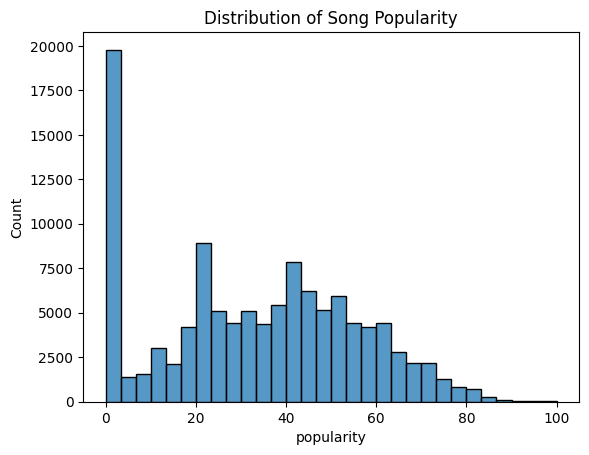

In [10]:
sns.histplot(df['popularity'], bins=30)
plt.title("Distribution of Song Popularity")
plt.show()

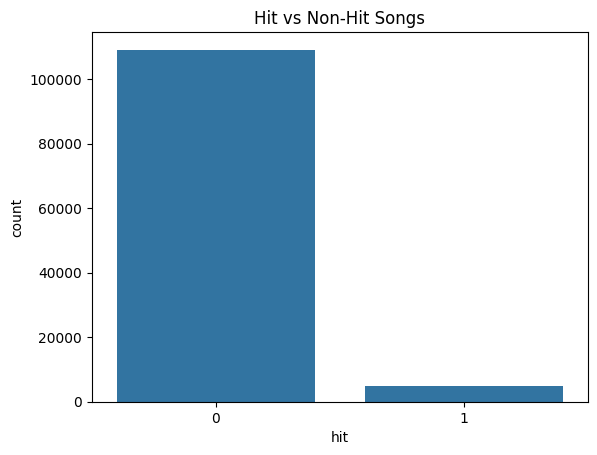

In [11]:
sns.countplot(x=df['hit'])
plt.title("Hit vs Non-Hit Songs")
plt.show()

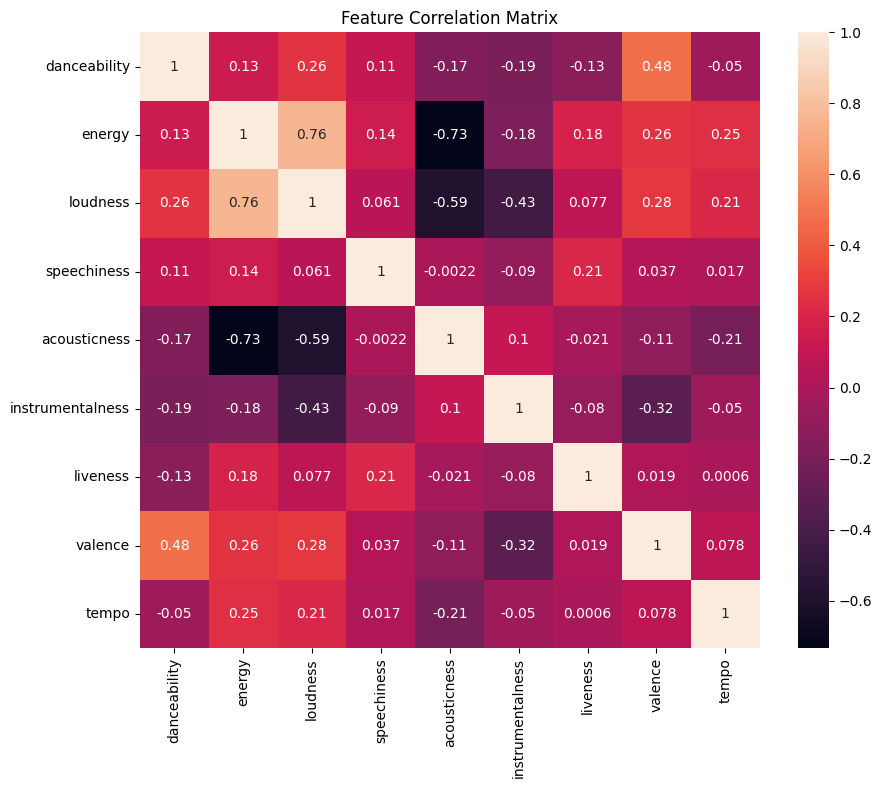

In [12]:
features = [
'danceability',
'energy',
'loudness',
'speechiness',
'acousticness',
'instrumentalness',
'liveness',
'valence',
'tempo'
]

corr = df[features].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True)
plt.title("Feature Correlation Matrix")
plt.show()

In [13]:
X = df[features]
y = df['hit']

In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

In [25]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [26]:
predictions = model.predict(X_test)

In [27]:
accuracy = accuracy_score(y_test, predictions)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.9810526315789474


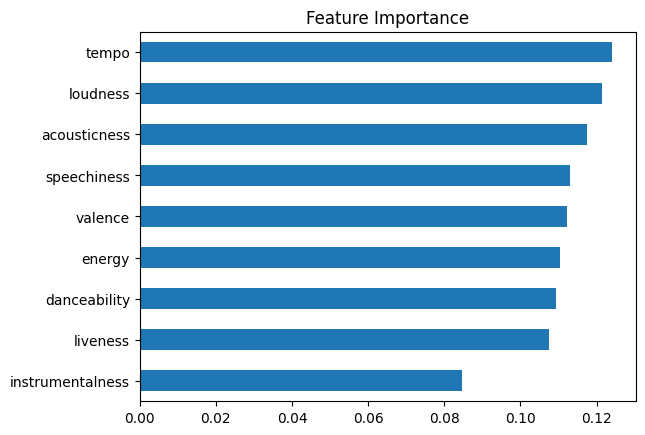

In [28]:
importance = model.feature_importances_
feature_importance = pd.Series(importance, index=features)
feature_importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

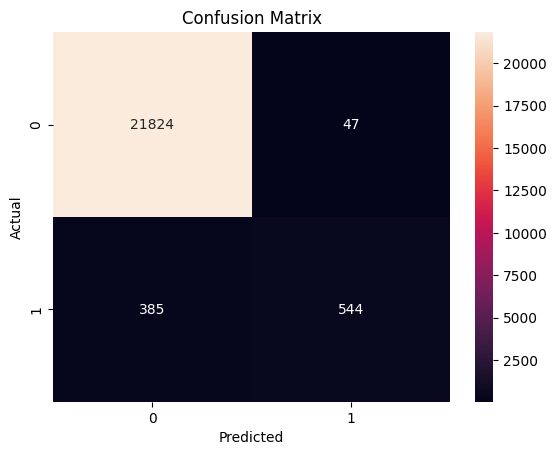

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Logistic Regression Model

In [30]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9592543859649123


## XGboost Model

In [32]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=250,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

In [33]:
xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score
xgb_accuracy = accuracy_score(y_test, xgb_predictions)
print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.9613157894736842


## Model Comparison

In [35]:
print("Model Comparison")
print("Logistic Regression:", lr_accuracy)
print("Random Forest:", accuracy)
print("XGBoost:", xgb_accuracy)

Model Comparison
Logistic Regression: 0.9592543859649123
Random Forest: 0.9810526315789474
XGBoost: 0.9613157894736842


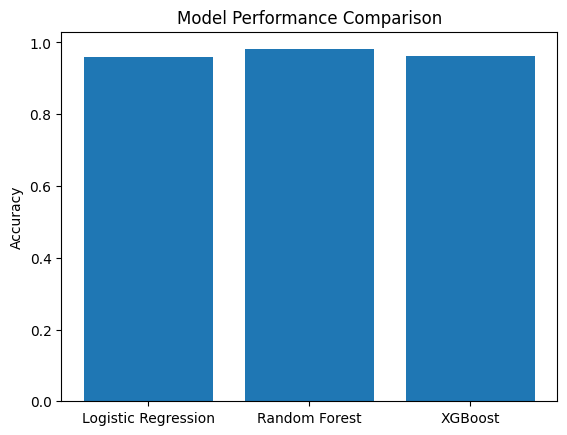

In [36]:
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
scores = [lr_accuracy, accuracy, xgb_accuracy]
plt.bar(models, scores)
plt.ylabel("Accuracy")
plt.title("Model Performance Comparison")
plt.show()

In [37]:
joblib.dump(model, "hit_song_model.pkl")

['hit_song_model.pkl']

## Conclusion

Three machine learning models were trained and evaluated.

Logistic Regression achieved approximately 95% accuracy, while Random Forest achieved the highest accuracy of around 98%. XGBoost also performed well but slightly below Random Forest.

Based on the evaluation results, Random Forest was selected as the best performing model for predicting Spotify hit songs.